In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [ ]:
print("Ready.")

Ready.


In [ ]:
df = yf.download("SPY", start="2016-01-01", end="2026-01-01", auto_adjust=True)
print(f"{len(df)} trading days downloaded")
df.columns = df.columns.get_level_values(0)
df.head()

[*********************100%***********************]  1 of 1 completed

2514 trading days downloaded


Price,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,169.471558,169.479984,167.422920,169.024738,222353500
2016-01-05,169.758209,170.213455,168.653805,169.791926,110845800
2016-01-06,167.616867,168.662251,166.588335,167.212190,152112600
2016-01-07,163.595459,166.453426,163.207647,164.674573,213436100
2016-01-08,161.799728,165.112954,161.513092,164.556532,209817200


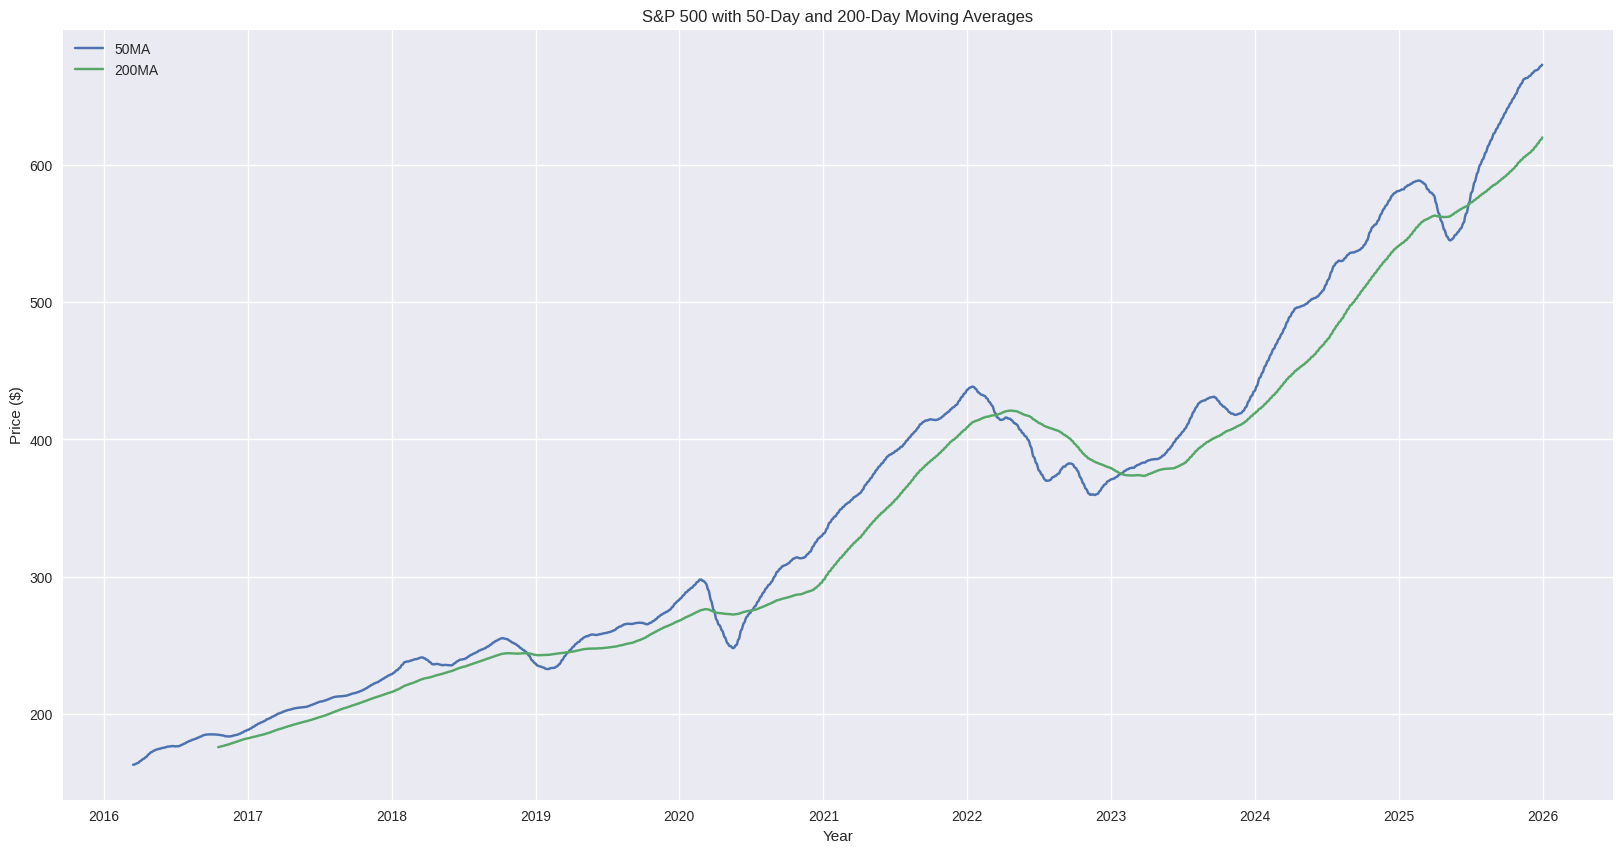

In [ ]:
df["50MA"] = df["Close"].rolling(50).mean()
df["200MA"] = df["Close"].rolling(200).mean()

plt.figure(figsize=(20,10))

plt.plot(df.index, df["50MA"], label ="50MA")
plt.plot(df.index, df["200MA"], label = "200MA")

plt.legend()
plt.title("S&P 500 with 50-Day and 200-Day Moving Averages")
plt.ylabel("Price ($)")
plt.xlabel("Year");


In [ ]:
# if 50-day MA > 200-day MA, that means you should buy S&P 500 ()

df["position"] = (df["50MA"] > df["200MA"]).astype(int)
df["position"]

,position
Date,
2016-01-04,0
2016-01-05,0
2016-01-06,0
2016-01-07,0
2016-01-08,0
...,...
2025-12-24,1
2025-12-26,1
2025-12-29,1


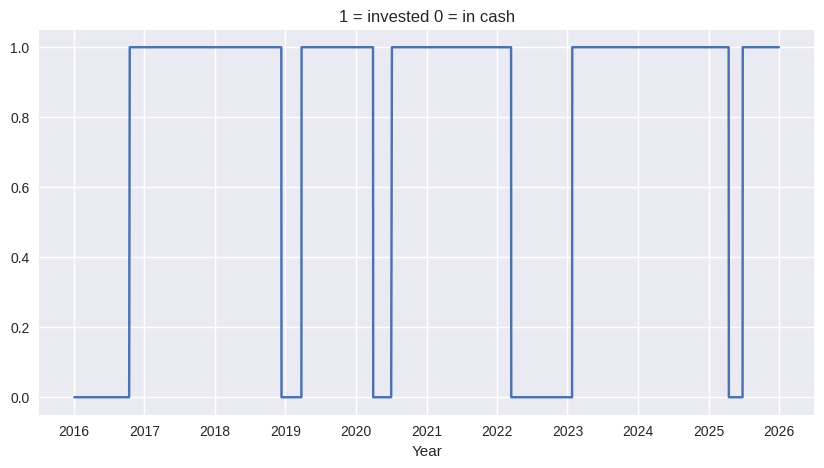

In [ ]:
plt.figure(figsize = (10, 5))
plt.plot(df["Close"].index, df["position"])
plt.xlabel("Year")
plt.title("1 = invested 0 = in cash");

In [ ]:
df["holding"] = df["position"].shift(1)
df["holding"]

,holding
Date,
2016-01-04,NaN
2016-01-05,0.0
2016-01-06,0.0
2016-01-07,0.0
2016-01-08,0.0
...,...
2025-12-24,1.0
2025-12-26,1.0
2025-12-29,1.0


In [ ]:
# cumprod() returns product cumulatively

df["market_return"] = df["Close"].pct_change()
df["strategy_return"] = df["holding"] * df["market_return"]

df["buy_hold_value"] = (1 + df["market_return"]).cumprod()
df["strategy_value"] = (1 + df["strategy_return"]).cumprod()

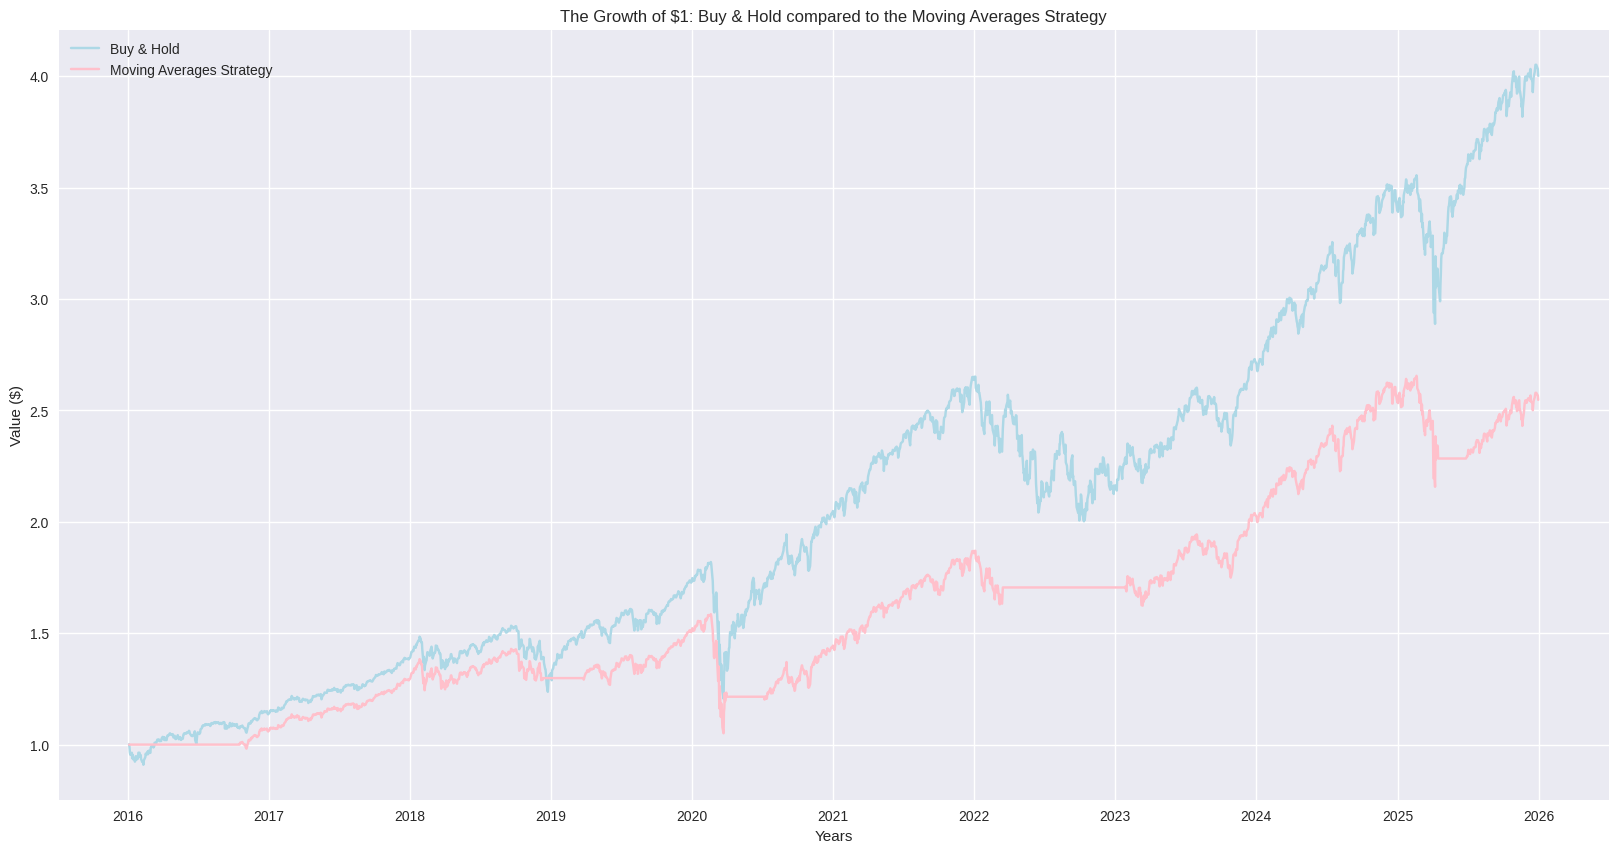

In [ ]:
plt.figure(figsize = (20,10))
plt.plot(df.index, df["buy_hold_value"], label = "Buy & Hold", color = "lightblue")
plt.plot(df.index, df["strategy_value"], label = "Moving Averages Strategy", color = "pink")
plt.style.use("seaborn-v0_8")

plt.title("The Growth of $1: Buy & Hold compared to the Moving Averages Strategy")
plt.legend()
plt.ylabel("Value ($)")
plt.xlabel("Years");

In [ ]:
# Important Values


def total_return (returns):
  return (1+ returns).prod() - 1

# Annualized Sharpe Ratio - return relative to risk (assuming Rf = 0) -- higher is better
def sharpe_ratio(returns):
  return returns.mean() / returns.std() * np.sqrt(252)

results = pd.DataFrame({
    "Buy & Hold":   [total_return(df["market_return"]),
                     sharpe_ratio(df["market_return"])],

    "Moving Average Strategy":
                    [total_return(df["strategy_return"]),
                     sharpe_ratio(df["strategy_return"])],
   }, index=["Total Return", "Sharpe Ratio"])

In [ ]:
results

,Buy & Hold,Moving Average Strategy
Total Return,3.002531,1.547781
Sharpe Ratio,0.862825,0.708021


I compared a popular trading strategy, the Moving Average Crossover, to simply buying and holding the S&P 500 over roughly 10 years (January 2016 - January 2026).

The Moving Average Strategy buys when the 50-day moving average is above the 200-day moving average, and sells (moves to cash) when it falls below. The Buy & Hold Strategy buys the S&P 500 at the start of the period and holds it the whole time. This strategy begins after the first 200 days so it is flat for teh first 200 trading days.

Tracking the growth of one dollar, it is shown graphically that the Buy & Hold Strategy grows 1 dollar to approximately 4 dollars whereas the Moving Average strategy only grows to about 2.5 dollars.

Numerically, the total return for the Buy & Hold Strategy is larger than that of the Moving Average Strategy, 3.00 vs 1.55. The Sharpe Ratio, the measure of return relative to risk, is also higher for the Buy & Hold Strategy meaning that this strategy generates higher risk-adjusted returns.

These figures do not include trading costs. Because the Moving Average Strategy trades while Buy & Hold does not, commissions and taxes would only widen the gap. The strategy trails before any costs are counted.

It is also remeberering that this time period was a mostly uninterrupted bull marekt, where staying invested wins. Therefore, this result could change with a different sample.

Overall, this experiment shows that the Moving Average Crossover failed to beat the benchmark.
